In [1]:
import json, os, sys, glob

In [2]:
json_list_file = 'best_model_list_X013-2.txt'

with open(json_list_file, 'r') as f:
    json_files = [line[:-1] if line.endswith('\n') else line for line in f.readlines()]

In [3]:
def lines_no_newlines(filename):
    with open(filename, 'r') as f:
        return [line[:-1] if line.endswith('\n') else line for line in f.readlines()]

def parse_clustering_log(json_fn):
    #Unpack json
    with open(json_fn, 'r') as g:
        json_params = json.load(g)
    
    #Determine the location of the save_dir from the json file
    model_name = json_params["model_name"]
    n_latents = json_params["latent_dim"]
    test_slice = json_params["test_slice"]
    data_dir = os.path.join(json_params["save_dir"], f'{model_name}/', f'{n_latents:04d}_latents/', f'rpt_{test_slice}/')

    lines = lines_no_newlines(os.path.join(data_dir, 'clustering', 'clustering_metric_log.txt'))
    i = 18
    kmeans = lines[i:i+2], lines[i+4:i+6], lines[i+8:i+10], lines[i+12:i+14], lines[i+16:i+18], lines[i+20:i+22]
    i = 42
    aggl = lines[i:i+2], lines[i+4:i+6], lines[i+8:i+10], lines[i+12:i+14], lines[i+16:i+18], lines[i+20:i+22]
    i=66
    hdbs = lines[i:i+2], lines[i+4:i+6], lines[i+8:i+10], lines[i+12:i+14], lines[i+16:i+18], lines[i+20:i+22]

    #Parse these to actual numbers
    # in order [rand ... (VAE, VAE_err, PCA, PCA_err)
    kmeans = [(float(elem[1].split(' ')[-3]),
               float(elem[1].split(' ')[-1]),
               float(elem[0].split(' ')[-3]),
               float(elem[0].split(' ')[-1])) for elem in kmeans]
    
    aggl = [(float(elem[1].split(' ')[-3]),
               float(elem[1].split(' ')[-1]),
               float(elem[0].split(' ')[-3]),
               float(elem[0].split(' ')[-1])) for elem in aggl]
    
    hdbs = [(float(elem[1].split(' ')[-3]),
               float(elem[1].split(' ')[-1]),
               float(elem[0].split(' ')[-3]),
               float(elem[0].split(' ')[-1])) for elem in hdbs]
    
    return kmeans, aggl, hdbs

In [44]:
import matplotlib.pyplot as plt
title_key = ['Rand Score',
             'Normalized MI Score',
             'Fowlkes-Mallows Score',
             'Silhouette Score',
             'Davies-Bouldin Score',
             'Calinski-Harabasz Score']

def plot_metric(metric, latents, title=None, method=0):
    """
    method=0 for kmeans, 1 for agglomerative, 2 for hdbscan
    """
    vae_val = [data[method][0] for data in metric]
    vae_err = [data[method][1] for data in metric]
    pca_val = [data[method][2] for data in metric]
    pca_err = [data[method][3] for data in metric]
    #print(vae_val, vae_err, pca_val, pca_err)

    plt.clf()
    plt.errorbar(x=latents, y=vae_val, yerr=vae_err, label='VAE')
    plt.errorbar(x=latents, y=pca_val, yerr=pca_err, label='PCA')
    if title is not None:
        plt.title(title)
    plt.xlabel('Num Latent/Component')
    plt.ylabel('Clustering Metric Value')
    if title is not None and 'Calinski' in title:
        plt.yscale('log')
    plt.xscale('log')
    plt.legend()
    plt.show()

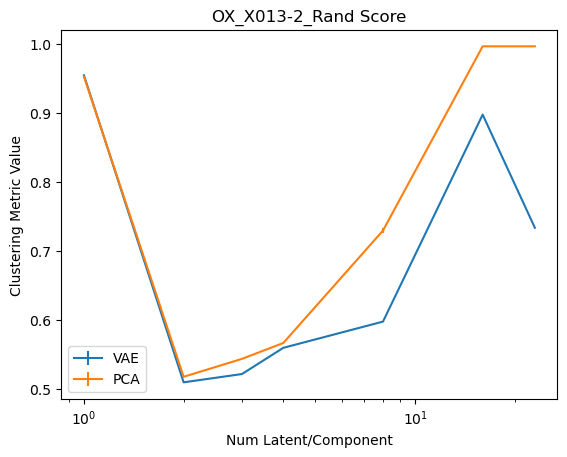

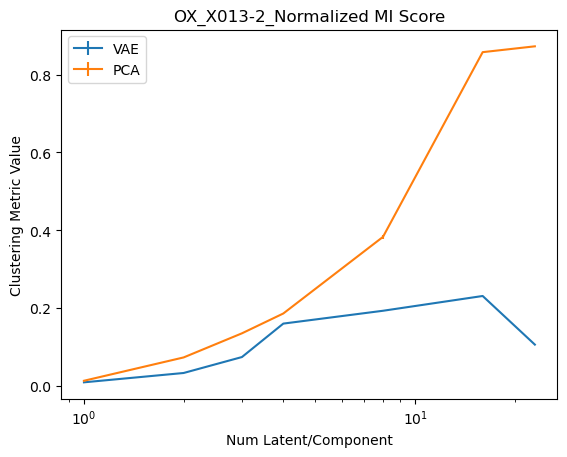

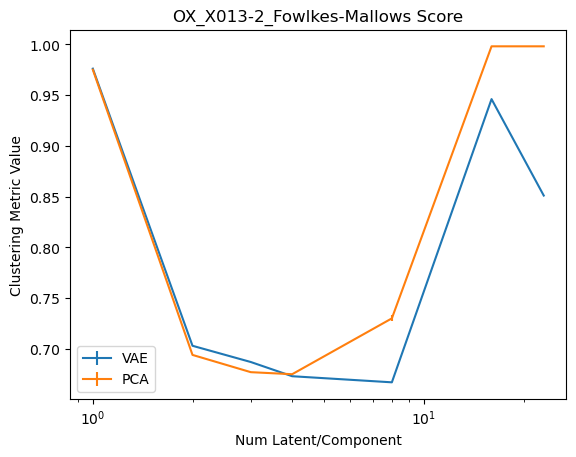

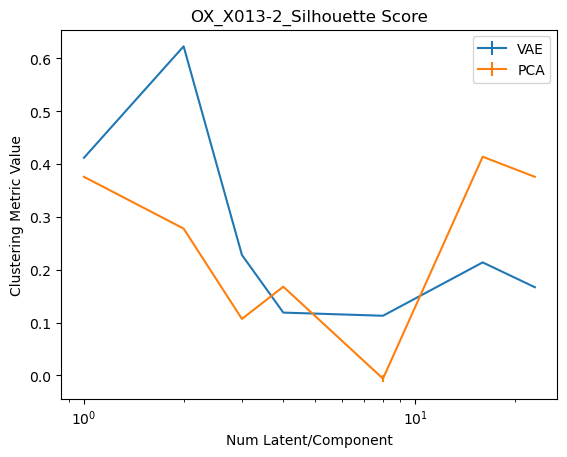

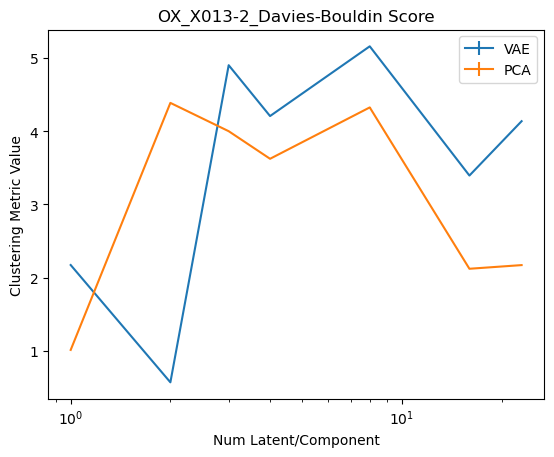

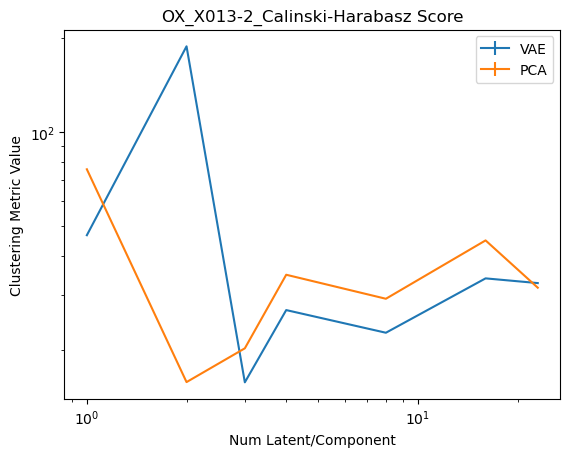

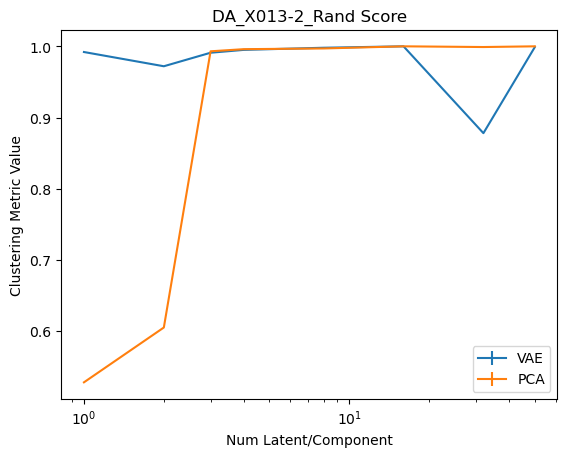

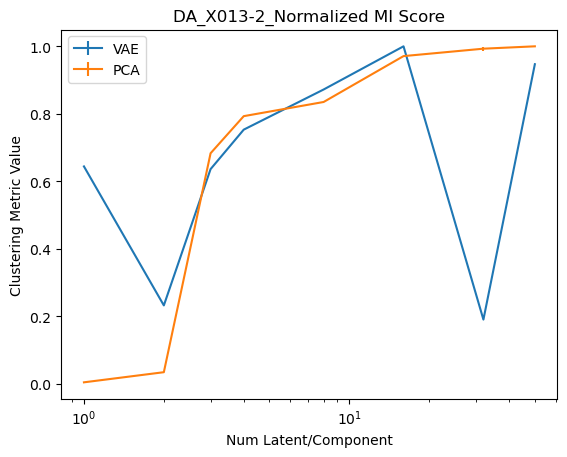

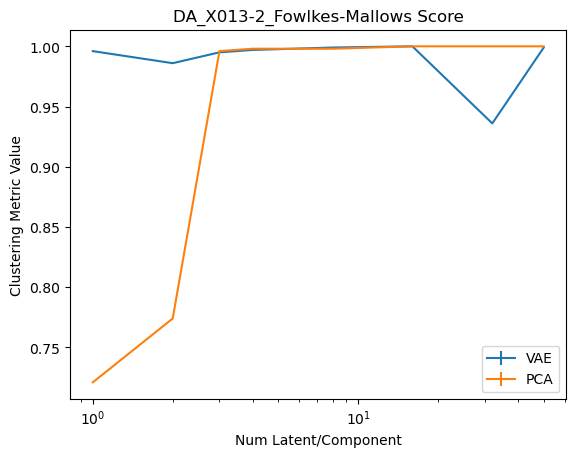

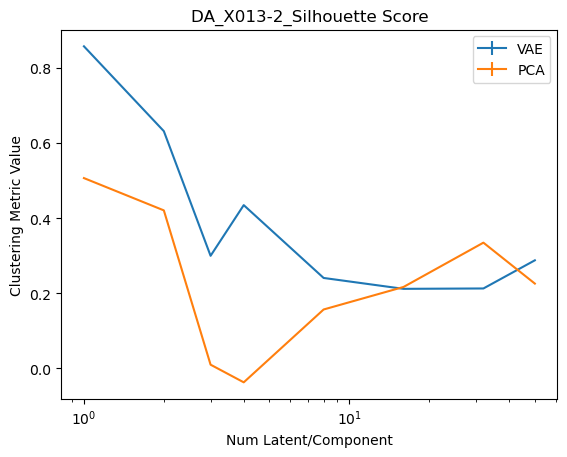

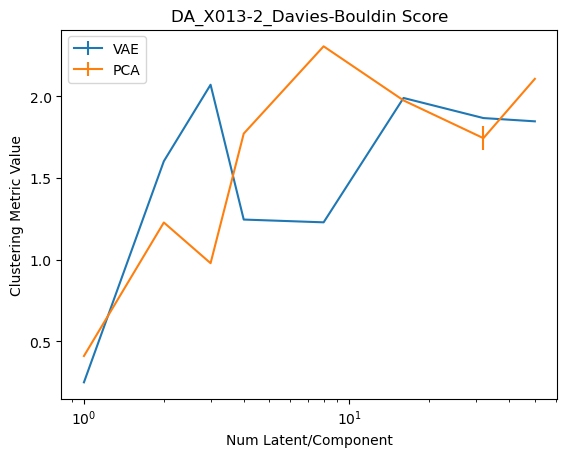

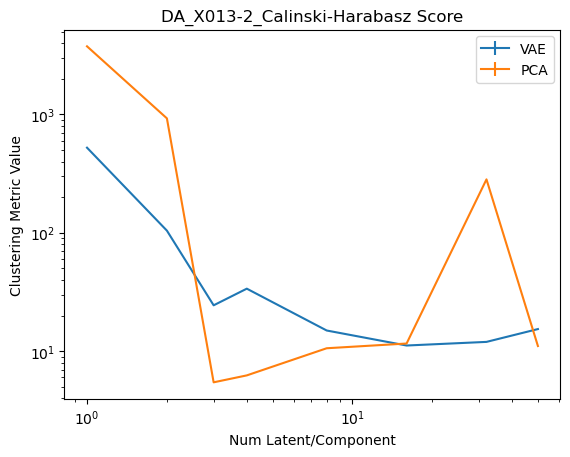

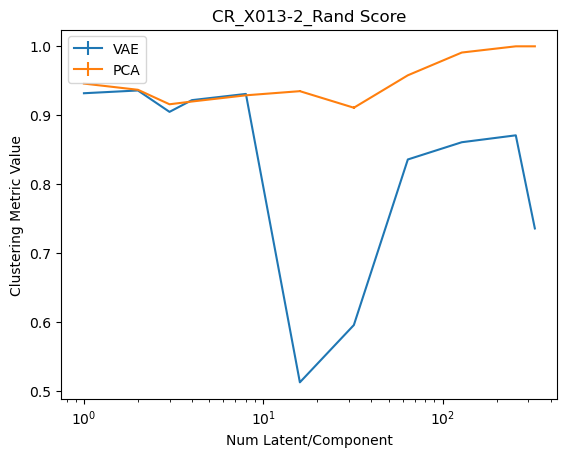

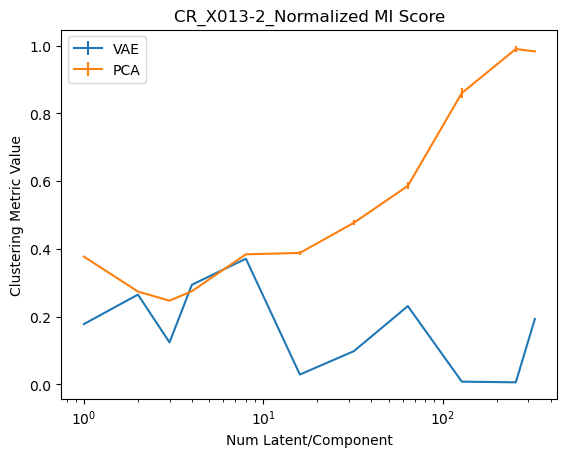

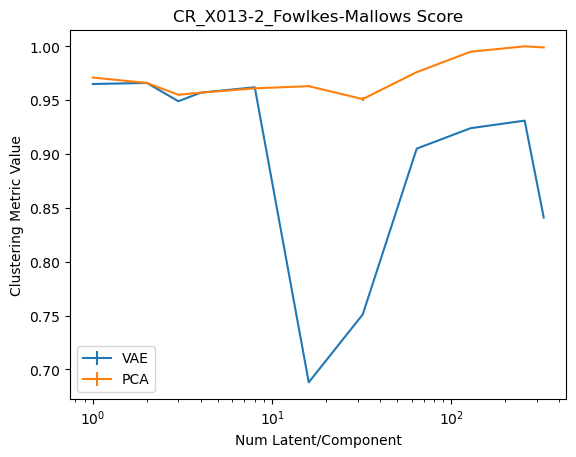

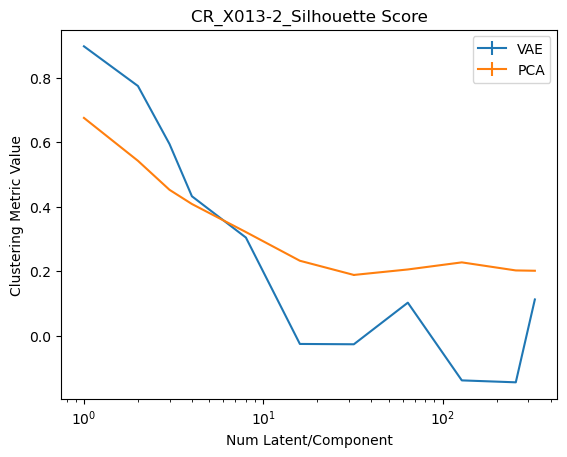

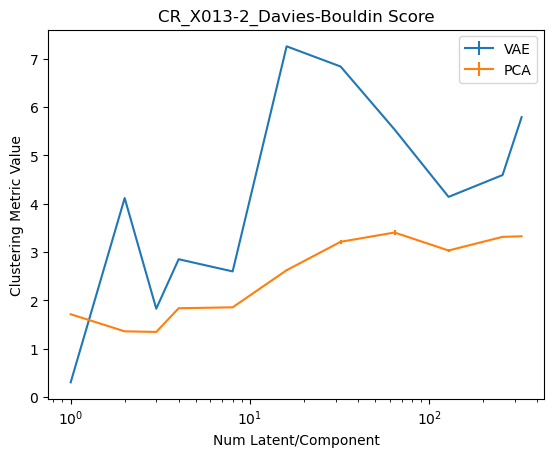

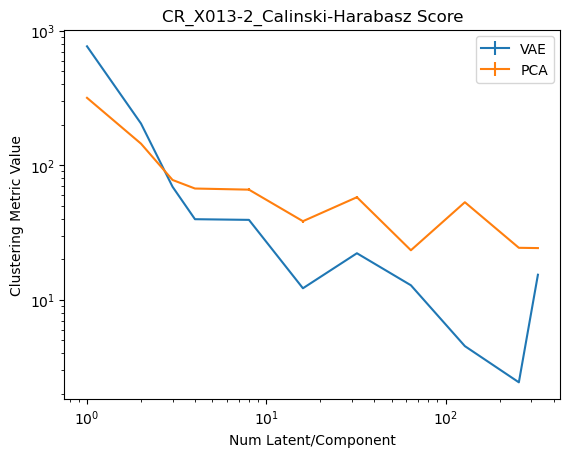

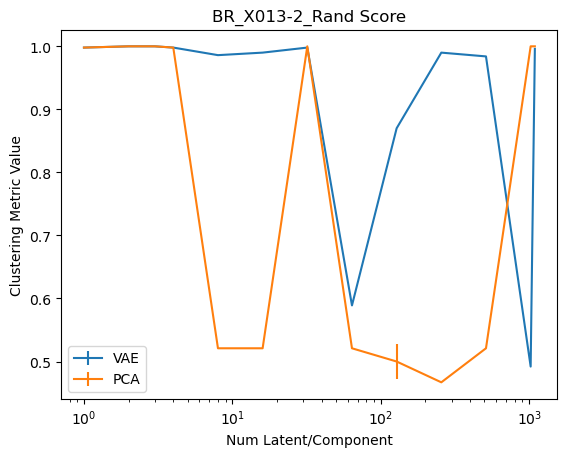

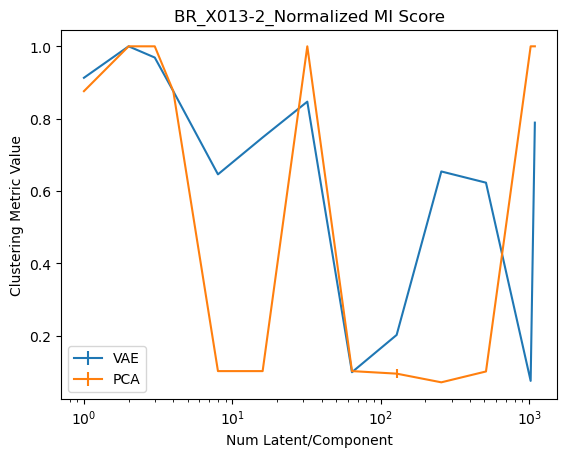

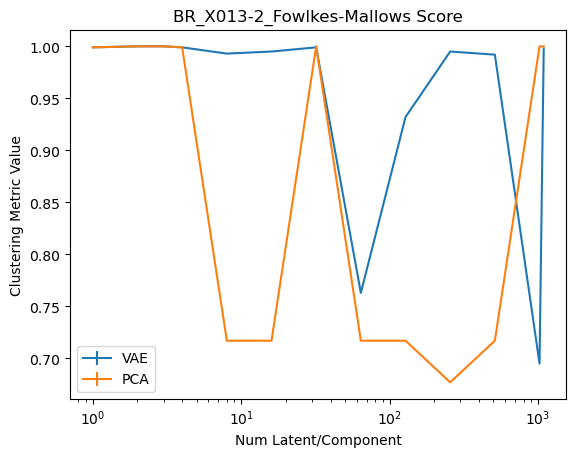

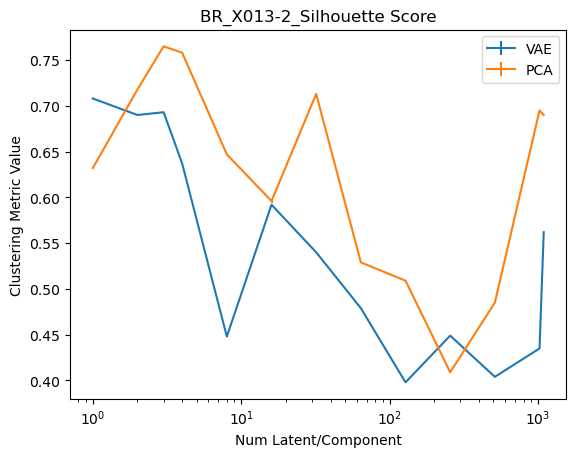

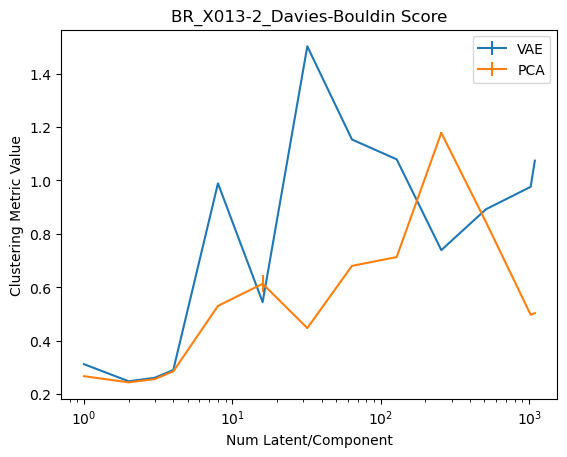

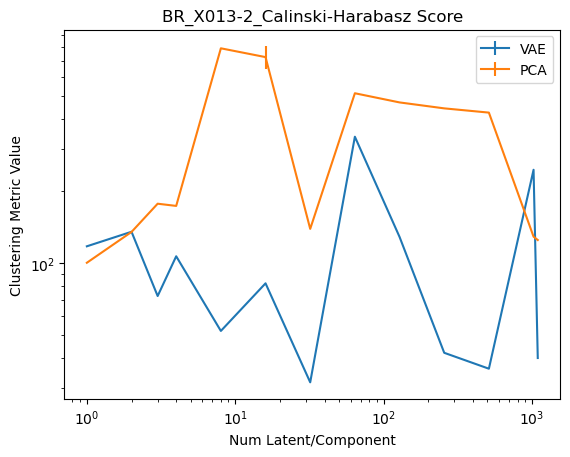

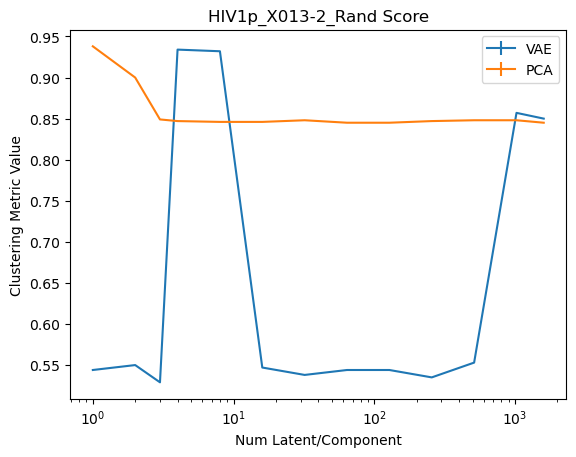

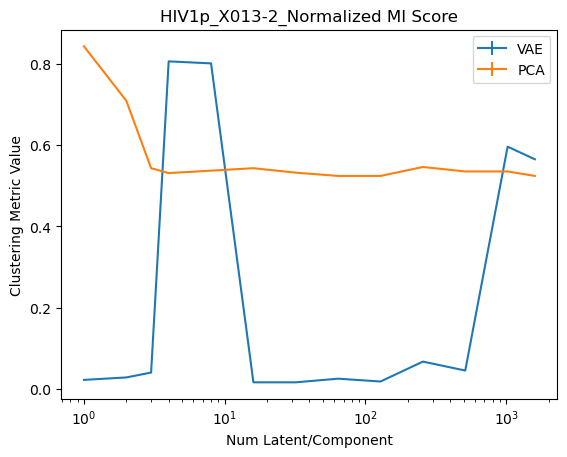

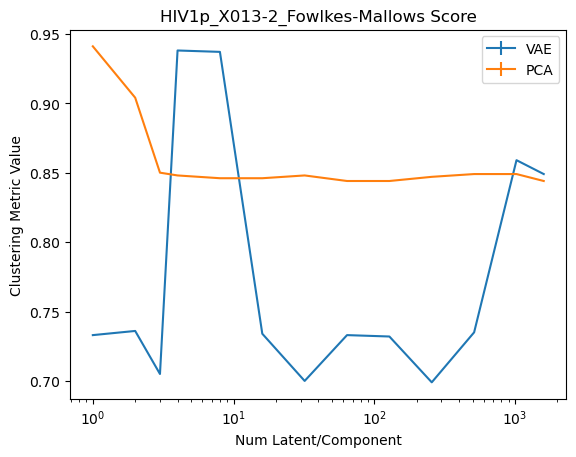

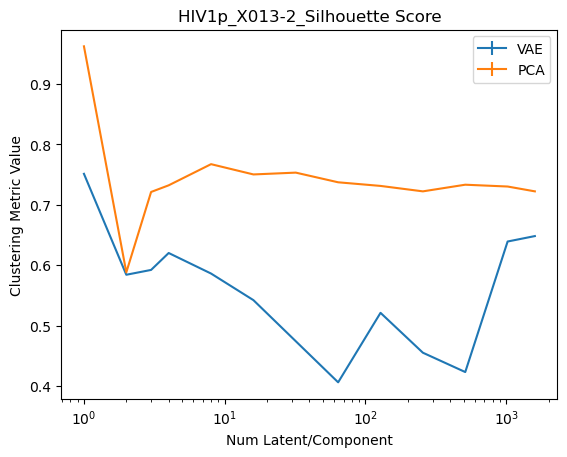

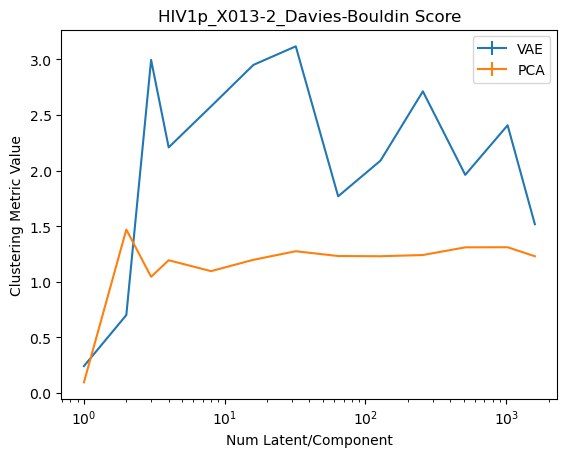

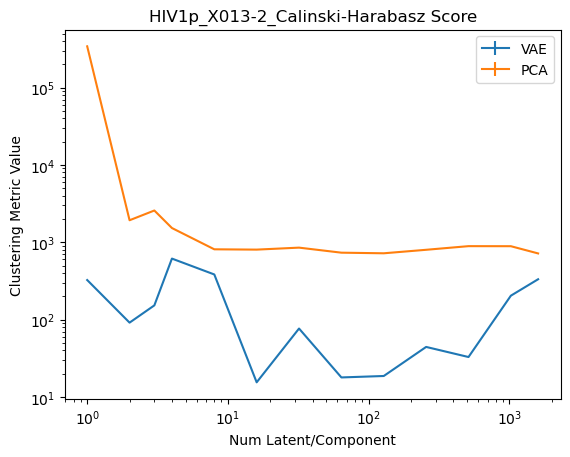

In [45]:
base_model = 'X013-2'
for prefix in ['OX_', 'DA_', 'CR_', 'BR_', 'HIV1p_']:
    
    model_name2load = prefix+base_model
    
    json_fns = [fi for fi in json_files if model_name2load in fi]
    latents = [int(fns.split('_')[-2]) for fns in json_fns]
    
    rand = []
    mi = []
    fomal = []
    sils = []
    davbol = []
    calhar = []
    
    for fn, lat in zip(json_fns, latents):
        kmeans, aggl, hdbs = parse_clustering_log(fn)
        rand.append([kmeans[0], aggl[0], hdbs[0]])
        mi.append([kmeans[1], aggl[1], hdbs[1]])
        fomal.append([kmeans[2], aggl[2], hdbs[2]])
        sils.append([kmeans[3], aggl[3], hdbs[3]])
        davbol.append([kmeans[4], aggl[4], hdbs[4]])
        calhar.append([kmeans[5], aggl[5], hdbs[5]])
    
    
    for i, metric in enumerate([rand, mi, fomal, sils, davbol, calhar]):
        title=title_key[i]
        plot_metric(metric, latents, method=2, title=model_name2load +'_'+title_key[i])